<a href="https://colab.research.google.com/github/PriyaVerma06/EDA-IPL/blob/fix-E4/notebooks/fix_E4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 1. Setup and Imports

import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# 2. Load Data

df = pd.read_csv("https://raw.githubusercontent.com/PriyaVerma06/EDA-IPL/main/data/matches.csv")

In [4]:
#3. Top 10 Venues

top_venues = df["venue"].value_counts().head(10).index
df_top = df[df["venue"].isin(top_venues)]


In [5]:
# 4. Create Bat First / Chase Labels

# If toss decision is 'bat' → team bats first
# If toss decision is 'field' → opponent bats first

df_top["bat_first_team"] = df_top.apply(
    lambda x: x["toss_winner"] if x["toss_decision"] == "bat"
    else (x["team1"] if x["toss_winner"] == x["team2"] else x["team2"]),
    axis=1
)

# Team chasing = other team
df_top["chasing_team"] = df_top.apply(
    lambda x: x["team2"] if x["bat_first_team"] == x["team1"] else x["team1"],
    axis=1
)


/tmp/ipykernel_6731/1606822476.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top["bat_first_team"] = df_top.apply(
/tmp/ipykernel_6731/1606822476.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top["chasing_team"] = df_top.apply(


In [6]:
# 5. Determine Match Outcome

df_top["bat_first_win"] = df_top["winner"] == df_top["bat_first_team"]
df_top["chasing_win"] = df_top["winner"] == df_top["chasing_team"]

/tmp/ipykernel_6731/2317093494.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top["bat_first_win"] = df_top["winner"] == df_top["bat_first_team"]
/tmp/ipykernel_6731/2317093494.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top["chasing_win"] = df_top["winner"] == df_top["chasing_team"]


In [7]:
# 6. Create Era Column
df_top["season"] = df_top["season"].str[:4].astype(int)

# 7. Create Era Column
df_top["era"] = df_top["season"].apply(
    lambda x: "Early IPL" if x < 2015 else "Modern IPL"
)

# Clean venue names (remove duplicates like ", Mumbai")
df_top["venue"] = df_top["venue"].str.replace(r",.*", "", regex=True)

/tmp/ipykernel_6731/699647952.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top["season"] = df_top["season"].str[:4].astype(int)
/tmp/ipykernel_6731/699647952.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top["era"] = df_top["season"].apply(
/tmp/ipykernel_6731/699647952.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

In [8]:
# 7. Aggregate Win Ratios

venue_stats = df_top.groupby(["venue", "era"]).agg({
    "bat_first_win": "mean",
    "chasing_win": "mean"
}).reset_index()

# Convert to percentage
venue_stats["bat_first_win"] *= 100
venue_stats["chasing_win"] *= 100

print(venue_stats)


                                  venue         era  bat_first_win  \
0   Dubai International Cricket Stadium   Early IPL      42.857143   
1   Dubai International Cricket Stadium  Modern IPL      51.282051   
2                          Eden Gardens   Early IPL      37.500000   
3                          Eden Gardens  Modern IPL      40.540541   
4                      Feroz Shah Kotla   Early IPL      43.902439   
5                      Feroz Shah Kotla  Modern IPL      47.368421   
6                 M Chinnaswamy Stadium   Early IPL      40.476190   
7                 M Chinnaswamy Stadium  Modern IPL      39.130435   
8                MA Chidambaram Stadium   Early IPL      60.975610   
9                MA Chidambaram Stadium  Modern IPL      85.714286   
10   Punjab Cricket Association Stadium   Early IPL      38.709677   
11   Punjab Cricket Association Stadium  Modern IPL      75.000000   
12   Rajiv Gandhi International Stadium   Early IPL      33.333333   
13   Rajiv Gandhi In

In [9]:
# 8. Pivot for Visualization

pivot_bat = venue_stats.pivot(index="venue", columns="era", values="bat_first_win")
pivot_chase = venue_stats.pivot(index="venue", columns="era", values="chasing_win")

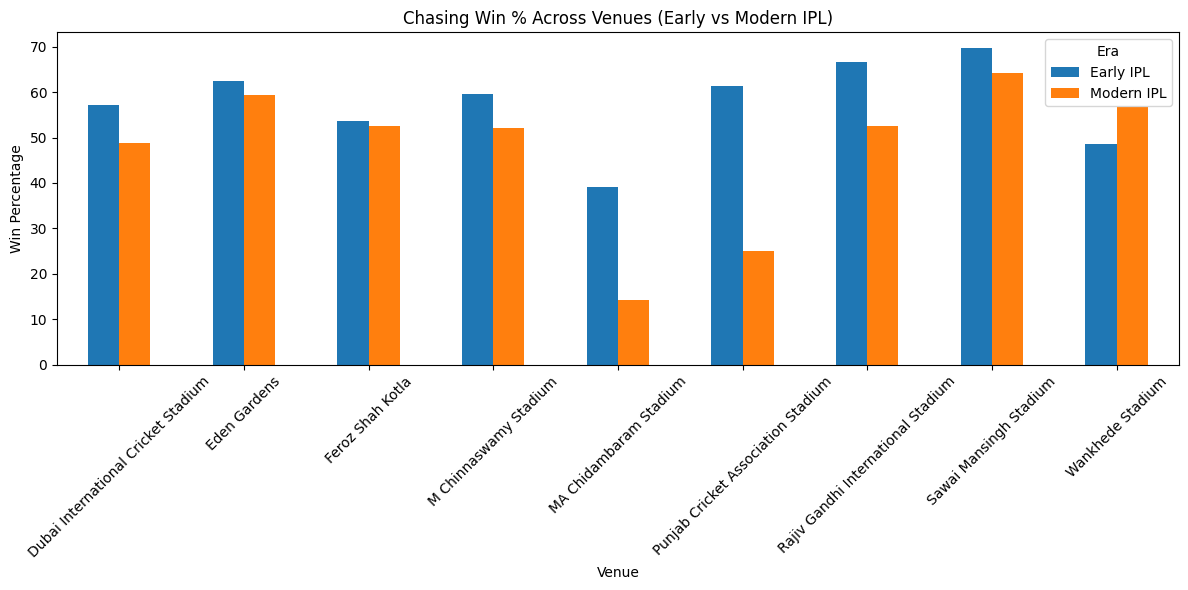

In [10]:
# 9. Visualization (Grouped Bar)

pivot_chase.plot(kind="bar", figsize=(12,6))

plt.title("Chasing Win % Across Venues (Early vs Modern IPL)")
plt.xlabel("Venue")
plt.ylabel("Win Percentage")
plt.xticks(rotation=45)

plt.legend(title="Era")
plt.tight_layout()
plt.show()